# Day 6 Baseline 建模：AI4I 2020 设备故障预测

本 notebook 的目标是完成第一版最小可行 baseline：在不做复杂特征工程、不做复杂调参的前提下，使用当前项目已经理解过的核心业务变量，训练一个可以解释、可以展示、可以衔接 Day 7 总结的故障预测模型。

当前阶段重点不是刷分，而是回答：仅使用基础运行状态字段时，模型能否识别少数故障样本。

## 1. Day 6 建模边界

- 目标变量：CSV 原始字段 `Machine failure`，对应 SQL 表中的 `Machine_failure`。
- 当前不使用 `TWF/HDF/PWF/OSF/RNF` 作为特征，因为它们是具体故障原因标记，更适合做解释或边界提醒；直接用于预测总故障标签容易造成标签泄漏。
- 当前不使用 `UDI` 和 `Product ID`，因为它们更像记录编号和产品编号，不是稳定的运行状态变量。
- 当前只做最小 baseline：Logistic Regression 和 XGBoost。
- 评价重点放在故障类 `1` 的 precision、recall、F1 和 confusion matrix，而不是只看 accuracy。

In [1]:
# 导入基础数据处理、建模和评估库
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

from xgboost import XGBClassifier

# 统一随机种子，保证结果可复现
RANDOM_STATE = 42

## 2. 读取数据

当前 notebook 默认从项目根目录 `C:\2020 AI4I\ai4i_predictive_maintenance` 运行，因此直接读取 `data/raw/ai4i2020.csv`。

In [2]:
df = pd.read_csv("../data/raw/ai4i2020.csv")

print("数据规模：", df.shape)
df.head()

数据规模： (10000, 14)


,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [6]:
# 快速确认字段和目标变量分布，避免建模前拿错列
print("字段列表：")
print(df.columns.tolist())

print("\n目标变量分布：")
print(df["Machine failure"].value_counts().sort_index())

print("\n目标变量占比：")
print((df["Machine failure"].value_counts(normalize=True).sort_index() * 100).round(2))

字段列表：
['UDI', 'Product ID', 'Type', 'Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'Machine failure', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF']

目标变量分布：
Machine failure
0    9661
1     339
Name: count, dtype: int64

目标变量占比：
Machine failure
0    96.61
1     3.39
Name: proportion, dtype: float64


## 3. 选择特征与目标

特征选择沿用 Day 3 / Day 5 已经观察过的业务变量：产品类型、温度、转速、扭矩、刀具磨损。这里先不新增复杂组合特征，目的是建立第一版可比较的基础结果。

In [7]:
target_col = "Machine failure"

feature_cols = [
    "Type",
    "Air temperature [K]",
    "Process temperature [K]",
    "Rotational speed [rpm]",
    "Torque [Nm]",
    "Tool wear [min]",
]

leakage_cols = ["TWF", "HDF", "PWF", "OSF", "RNF"]
id_cols = ["UDI", "Product ID"]

print("本次使用的特征：", feature_cols)
print("本次暂不使用的编号字段：", id_cols)
print("本次暂不作为预测特征的故障原因字段：", leakage_cols)

X_raw = df[feature_cols].copy()
y = df[target_col].copy()

本次使用的特征： ['Type', 'Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]']
本次暂不使用的编号字段： ['UDI', 'Product ID']
本次暂不作为预测特征的故障原因字段： ['TWF', 'HDF', 'PWF', 'OSF', 'RNF']


## 4. 基础预处理

`Type` 是类别字段，需要做 one-hot 编码。其余数值字段保持原始含义，不在第一版 baseline 中做复杂变换。

In [8]:
# 对 Type 做最基础的 one-hot 编码；保留全部类别，方便后续解释
X = pd.get_dummies(X_raw, columns=["Type"], drop_first=False)

# XGBoost 不接受包含 [] 或 < 的特征名，这里只对建模矩阵列名做安全化处理
# 原始数据字段和业务含义不变，后续解释仍然可以对应回原始变量
safe_columns = (
    pd.Series(X.columns)
    .str.replace("[", "", regex=False)
    .str.replace("]", "", regex=False)
    .str.replace("<", "lt", regex=False)
    .str.replace(">", "gt", regex=False)
    .str.replace(" ", "_", regex=False)
)
X.columns = safe_columns

print("建模特征列：")
print(X.columns.tolist())
print("\n建模矩阵规模：", X.shape)
X.head()

建模特征列：
['Air_temperature_K', 'Process_temperature_K', 'Rotational_speed_rpm', 'Torque_Nm', 'Tool_wear_min', 'Type_H', 'Type_L', 'Type_M']

建模矩阵规模： (10000, 8)


,Air_temperature_K,Process_temperature_K,Rotational_speed_rpm,Torque_Nm,Tool_wear_min,Type_H,Type_L,Type_M
0,298.1,308.6,1551,42.8,0,False,False,True
1,298.2,308.7,1408,46.3,3,False,True,False
2,298.1,308.5,1498,49.4,5,False,True,False
3,298.2,308.6,1433,39.5,7,False,True,False
4,298.2,308.7,1408,40.0,9,False,True,False


## 5. 划分训练集和测试集

故障样本占比只有约 3.39%，因此划分数据时使用 `stratify=y`，让训练集和测试集中的故障比例尽量保持一致。

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y,
)

print("训练集规模：", X_train.shape)
print("测试集规模：", X_test.shape)

print("\n训练集目标分布：")
print(y_train.value_counts().sort_index())

print("\n测试集目标分布：")
print(y_test.value_counts().sort_index())

训练集规模： (8000, 8)
测试集规模： (2000, 8)

训练集目标分布：
Machine failure
0    7729
1     271
Name: count, dtype: int64

测试集目标分布：
Machine failure
0    1932
1      68
Name: count, dtype: int64


## 6. 训练 baseline 模型

这里保留两个模型：

1. `Logistic Regression`：可解释性强，作为最基础的线性 baseline。
2. `XGBoost`：训练速度快，能捕捉非线性关系，作为当前 MVP 阶段的树模型 baseline。

由于故障样本明显少于正常样本，两个模型都使用最基础的不平衡处理参数，但不做复杂采样和调参。

In [10]:
# Logistic Regression 对特征尺度敏感，因此只给它做标准化
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

log_reg = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=RANDOM_STATE,
)
log_reg.fit(X_train_scaled, y_train)

# XGBoost 使用 scale_pos_weight 处理类别不平衡
negative_cnt = (y_train == 0).sum()
positive_cnt = (y_train == 1).sum()
scale_pos_weight = negative_cnt / positive_cnt

xgb_model = XGBClassifier(
    n_estimators=120,
    max_depth=3,
    learning_rate=0.08,
    subsample=0.9,
    colsample_bytree=0.9,
    objective="binary:logistic",
    eval_metric="logloss",
    tree_method="hist",
    scale_pos_weight=scale_pos_weight,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
xgb_model.fit(X_train, y_train)

print("模型训练完成。")
print("XGBoost scale_pos_weight：", round(scale_pos_weight, 2))

模型训练完成。
XGBoost scale_pos_weight： 28.52


## 7. 模型评估

本项目的故障样本很少，因此不能只看 accuracy。这里重点看故障类 `1` 的 precision、recall 和 F1-score。

- precision：模型预测为故障的样本中，有多少是真的故障。
- recall：真实故障样本中，有多少被模型识别出来。
- F1-score：precision 和 recall 的综合表现。

In [11]:
def evaluate_model(model_name, y_true, y_pred):
    """输出基础分类指标，并返回故障类的核心指标。"""
    print(f"===== {model_name} =====")
    print("Confusion matrix:")
    print(confusion_matrix(y_true, y_pred))
    print("\nClassification report:")
    print(classification_report(y_true, y_pred, digits=3, zero_division=0))

    report = classification_report(y_true, y_pred, output_dict=True, zero_division=0)
    return {
        "model": model_name,
        "accuracy": report["accuracy"],
        "failure_precision": report["1"]["precision"],
        "failure_recall": report["1"]["recall"],
        "failure_f1": report["1"]["f1-score"],
    }


log_reg_pred = log_reg.predict(X_test_scaled)
xgb_pred = xgb_model.predict(X_test)

results = []
results.append(evaluate_model("Logistic Regression", y_test, log_reg_pred))
results.append(evaluate_model("XGBoost", y_test, xgb_pred))

===== Logistic Regression =====
Confusion matrix:
[[1594  338]
 [  12   56]]

Classification report:
              precision    recall  f1-score   support

           0      0.993     0.825     0.901      1932
           1      0.142     0.824     0.242        68

    accuracy                          0.825      2000
   macro avg      0.567     0.824     0.572      2000
weighted avg      0.964     0.825     0.879      2000

===== XGBoost =====
Confusion matrix:
[[1787  145]
 [   8   60]]

Classification report:
              precision    recall  f1-score   support

           0      0.996     0.925     0.959      1932
           1      0.293     0.882     0.440        68

    accuracy                          0.923      2000
   macro avg      0.644     0.904     0.699      2000
weighted avg      0.972     0.923     0.941      2000



In [12]:
metrics_df = pd.DataFrame(results)
metrics_df = metrics_df.sort_values("failure_f1", ascending=False).reset_index(drop=True)
metrics_df

,model,accuracy,failure_precision,failure_recall,failure_f1
0,XGBoost,0.9235,0.292683,0.882353,0.439560
1,Logistic Regression,0.8250,0.142132,0.823529,0.242424


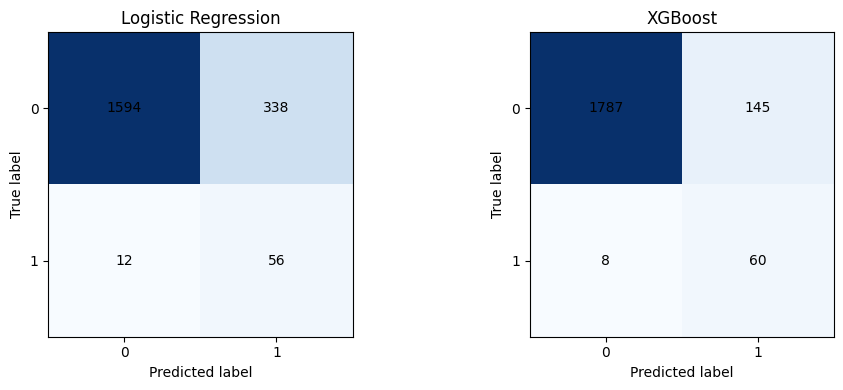

In [13]:
# 用图表查看两个模型的混淆矩阵，方便 Day 7 做项目展示时引用
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for ax, model_name, y_pred in zip(
    axes,
    ["Logistic Regression", "XGBoost"],
    [log_reg_pred, xgb_pred],
):
    cm = confusion_matrix(y_test, y_pred)
    ax.imshow(cm, cmap="Blues")
    ax.set_title(model_name)
    ax.set_xlabel("Predicted label")
    ax.set_ylabel("True label")
    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, cm[i, j], ha="center", va="center", color="black")

plt.tight_layout()
plt.show()

## 8. 轻量查看 XGBoost 特征重要性

这里不是做复杂解释模型，只是查看第一版树模型更关注哪些基础变量，方便和 Day 3 / Day 5 的业务发现互相印证。

In [14]:
feature_importance = pd.DataFrame({
    "feature": X.columns,
    "importance": xgb_model.feature_importances_,
}).sort_values("importance", ascending=False)

feature_importance

,feature,importance
2,Rotational_speed_rpm,0.282618
3,Torque_Nm,0.246789
4,Tool_wear_min,0.212733
0,Air_temperature_K,0.130895
1,Process_temperature_K,0.056494
7,Type_M,0.041198
6,Type_L,0.023335
5,Type_H,0.005938


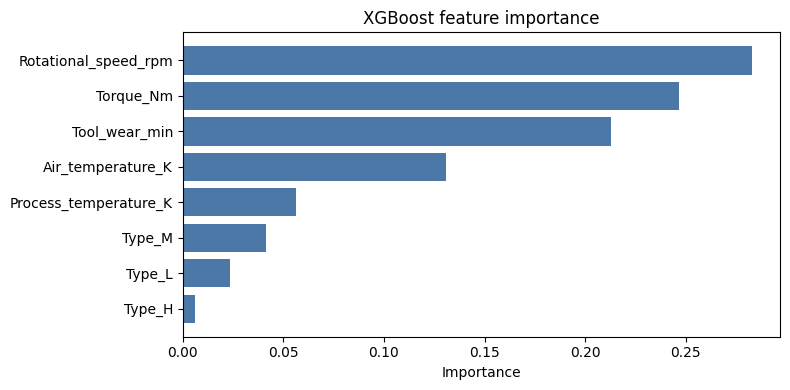

In [15]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(feature_importance["feature"], feature_importance["importance"], color="#4C78A8")
ax.invert_yaxis()
ax.set_title("XGBoost feature importance")
ax.set_xlabel("Importance")
plt.tight_layout()
plt.show()

## 9. Day 6 小结

本次 baseline 的目标是先跑通从业务分析到建模评估的最小闭环。当前模型只使用基础运行状态字段和产品类型，没有加入复杂特征工程，也没有使用具体故障原因字段 `TWF/HDF/PWF/OSF/RNF`，因此结果可以作为后续迭代的基础对照。

解读结果时需要优先关注故障类 `1` 的 recall 和 F1-score。如果模型 accuracy 很高但故障类 recall 很低，说明模型主要学会了识别多数类正常样本，对预测性维护场景的价值有限。

Day 7 可以基于本 notebook 的评估结果，整理 README、summary 和关键图表；如果后续继续迭代，再考虑加入少量业务特征，例如温差、功率近似值或高磨损标记。

## 10. 阈值调优与 PR 曲线分析

前面的 XGBoost baseline 默认使用 `0.5` 作为分类阈值。这个阈值可以作为对照，但不一定是预测性维护场景下最合理的业务阈值。

本节只基于已经训练好的 `xgb_model` 和测试集预测概率做阈值分析，不新增特征、不调参、不做交叉验证，也不改变前面的 baseline 结果。目标是在保留较高故障召回率的同时，观察是否可以通过阈值选择提升 precision / F1，并减少不必要的误报。


In [16]:
import numpy as np

from sklearn.metrics import (
    average_precision_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    f1_score,
    fbeta_score,
)


### 10.1 保留默认 0.5 阈值结果

这里先把当前 XGBoost 默认阈值 `0.5` 的结果单独整理出来，作为后续阈值比较的 baseline 对照。


In [17]:
y_proba = xgb_model.predict_proba(X_test)[:, 1]
xgb_pred_05 = (y_proba >= 0.5).astype(int)

cm_05 = confusion_matrix(y_test, xgb_pred_05, labels=[0, 1])
tn_05, fp_05, fn_05, tp_05 = cm_05.ravel()

default_threshold_result = pd.DataFrame([
    {
        "threshold": 0.5,
        "precision": precision_score(y_test, xgb_pred_05, zero_division=0),
        "recall": recall_score(y_test, xgb_pred_05, zero_division=0),
        "f1": f1_score(y_test, xgb_pred_05, zero_division=0),
        "f2": fbeta_score(y_test, xgb_pred_05, beta=2, zero_division=0),
        "TP": tp_05,
        "FP": fp_05,
        "TN": tn_05,
        "FN": fn_05,
    }
])

print("XGBoost default threshold = 0.5")
print("Confusion matrix:")
print(cm_05)
default_threshold_result.round(3)


XGBoost default threshold = 0.5
Confusion matrix:
[[1787  145]
 [   8   60]]


,threshold,precision,recall,f1,f2,TP,FP,TN,FN
0,0.5,0.293,0.882,0.44,0.629,60,145,1787,8


### 10.2 Precision-Recall Curve 与 Average Precision

由于故障样本占比很低，Precision-Recall Curve 比 ROC 曲线更适合观察少数故障类的识别质量。Average Precision 可以理解为 PR 曲线下的综合表现，数值越高表示模型越能把真实故障样本排在更高风险位置。


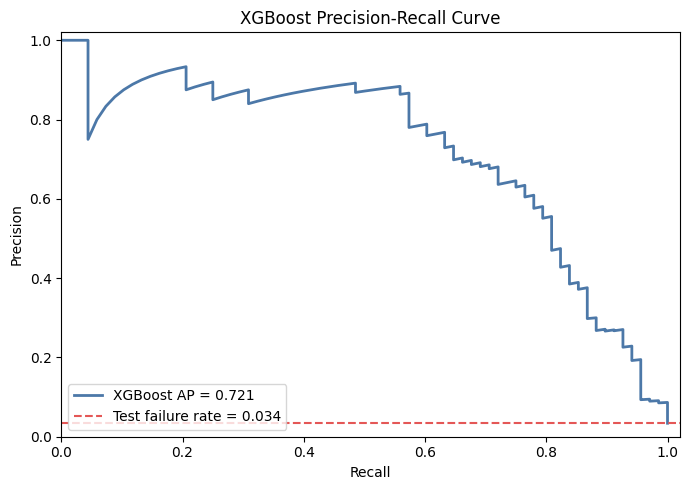

Average Precision / PR-AUC: 0.721
Test failure rate baseline: 0.034


In [18]:
precision_curve, recall_curve, pr_thresholds = precision_recall_curve(y_test, y_proba)
average_precision = average_precision_score(y_test, y_proba)
baseline_failure_rate = y_test.mean()

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(recall_curve, precision_curve, color="#4C78A8", linewidth=2, label=f"XGBoost AP = {average_precision:.3f}")
ax.axhline(
    baseline_failure_rate,
    color="#E45756",
    linestyle="--",
    linewidth=1.5,
    label=f"Test failure rate = {baseline_failure_rate:.3f}",
)
ax.set_title("XGBoost Precision-Recall Curve")
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_xlim(0, 1.02)
ax.set_ylim(0, 1.02)
ax.legend(loc="lower left")
plt.tight_layout()
plt.show()

print("Average Precision / PR-AUC:", round(average_precision, 3))
print("Test failure rate baseline:", round(baseline_failure_rate, 3))


### 10.3 Threshold 对比表

下面遍历 `0.10` 到 `0.90` 的多个阈值，观察每个阈值下的 precision、recall、F1、F2 和混淆矩阵组成。F2 比 F1 更重视 recall，适合预测性维护中“漏报故障成本较高”的场景参考。


In [19]:
def threshold_metrics(y_true, y_score, threshold):
    """计算单个阈值下的核心分类指标和混淆矩阵组成。"""
    y_pred = (y_score >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()

    return {
        "threshold": threshold,
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "f2": fbeta_score(y_true, y_pred, beta=2, zero_division=0),
        "TP": tp,
        "FP": fp,
        "TN": tn,
        "FN": fn,
    }

thresholds = np.round(np.arange(0.10, 0.91, 0.05), 2)
threshold_table = pd.DataFrame([
    threshold_metrics(y_test, y_proba, threshold)
    for threshold in thresholds
])

threshold_table.round(3)


,threshold,precision,recall,f1,f2,TP,FP,TN,FN
0,0.10,0.168,0.956,0.285,0.492,65,323,1609,3
1,0.15,0.184,0.956,0.308,0.519,65,289,1643,3
2,0.20,0.200,0.941,0.330,0.541,64,256,1676,4
3,0.25,0.220,0.941,0.357,0.568,64,227,1705,4
4,0.30,0.227,0.926,0.365,0.574,63,214,1718,5
5,0.35,0.247,0.926,0.390,0.598,63,192,1740,5
6,0.40,0.265,0.926,0.412,0.618,63,175,1757,5
7,0.45,0.271,0.882,0.415,0.609,60,161,1771,8
8,0.50,0.293,0.882,0.440,0.629,60,145,1787,8
9,0.55,0.317,0.868,0.465,0.644,59,127,1805,9


### 10.4 候选阈值选择

这里保留 4 个关键候选点：默认阈值、F1 最优阈值、F2 最优阈值，以及一个偏向召回率的预测性维护候选阈值。

召回优先候选阈值选择 `0.40`：相比默认 `0.50`，它会多抓回一部分故障样本，但误报也会增加，因此它更适合“漏报成本明显高于误报成本”的场景，而不是直接作为唯一最佳阈值。


In [20]:
def get_threshold_row(table, threshold):
    return table.loc[np.isclose(table["threshold"], threshold)].iloc[0]

f1_best_row = threshold_table.loc[threshold_table["f1"].idxmax()]
f2_best_row = threshold_table.loc[threshold_table["f2"].idxmax()]
default_row = get_threshold_row(threshold_table, 0.50)
recall_oriented_row = get_threshold_row(threshold_table, 0.40)

candidate_thresholds = pd.DataFrame([
    {"candidate": "Default 0.50", "reason": "当前 XGBoost 默认判定阈值", **default_row.to_dict()},
    {"candidate": "Recall-oriented 0.40", "reason": "减少漏报，适合更重视故障召回的维护筛查", **recall_oriented_row.to_dict()},
    {"candidate": "Best F2", "reason": "在本轮阈值网格中更重视 recall 的综合最优", **f2_best_row.to_dict()},
    {"candidate": "Best F1", "reason": "在本轮阈值网格中 precision/recall 平衡最优", **f1_best_row.to_dict()},
])

candidate_thresholds = candidate_thresholds[
    ["candidate", "reason", "threshold", "precision", "recall", "f1", "f2", "TP", "FP", "TN", "FN"]
]

candidate_thresholds.round(3)


,candidate,reason,threshold,precision,recall,f1,f2,TP,FP,TN,FN
0,Default 0.50,当前 XGBoost 默认判定阈值,0.50,0.293,0.882,0.440,0.629,60.0,145.0,1787.0,8.0
1,Recall-oriented 0.40,减少漏报，适合更重视故障召回的维护筛查,0.40,0.265,0.926,0.412,0.618,63.0,175.0,1757.0,5.0
2,Best F2,在本轮阈值网格中更重视 recall 的综合最优,0.80,0.602,0.779,0.679,0.736,53.0,35.0,1897.0,15.0
3,Best F1,在本轮阈值网格中 precision/recall 平衡最优,0.85,0.641,0.735,0.685,0.714,50.0,28.0,1904.0,18.0


### 10.5 候选阈值的混淆矩阵

下面只输出 4 个关键阈值的指标和混淆矩阵，避免被过多阈值淹没。混淆矩阵格式为：行是真实标签，列是预测标签。


In [21]:
for _, row in candidate_thresholds.iterrows():
    threshold = row["threshold"]
    y_pred_threshold = (y_proba >= threshold).astype(int)
    cm = confusion_matrix(y_test, y_pred_threshold, labels=[0, 1])

    print(f"===== {row['candidate']} | threshold = {threshold:.2f} =====")
    print(
        f"precision={row['precision']:.3f}, "
        f"recall={row['recall']:.3f}, "
        f"f1={row['f1']:.3f}, "
        f"f2={row['f2']:.3f}"
    )
    print(pd.DataFrame(cm, index=["True 0", "True 1"], columns=["Pred 0", "Pred 1"]))
    print()


===== Default 0.50 | threshold = 0.50 =====
precision=0.293, recall=0.882, f1=0.440, f2=0.629
        Pred 0  Pred 1
True 0    1787     145
True 1       8      60

===== Recall-oriented 0.40 | threshold = 0.40 =====
precision=0.265, recall=0.926, f1=0.412, f2=0.618
        Pred 0  Pred 1
True 0    1757     175
True 1       5      63

===== Best F2 | threshold = 0.80 =====
precision=0.602, recall=0.779, f1=0.679, f2=0.736
        Pred 0  Pred 1
True 0    1897      35
True 1      15      53

===== Best F1 | threshold = 0.85 =====
precision=0.641, recall=0.735, f1=0.685, f2=0.714
        Pred 0  Pred 1
True 0    1904      28
True 1      18      50



## 11. Day1 阈值调优小结

默认 `0.5` 阈值不是天然最合理的业务阈值，它只是分类模型常用的默认切分点。在当前测试集上，默认阈值下 XGBoost 的故障类表现为 `precision=0.293`、`recall=0.882`、`F1=0.440`、`F2=0.629`，能够抓回多数故障，但误报仍然较多。

本轮 XGBoost 的 Average Precision / PR-AUC 约为 `0.721`，明显高于测试集故障率基线 `0.034`。这说明模型输出的故障概率排序是有价值的：真实故障样本整体更容易被排到高风险区间。因此，阈值调优是有意义的，而不是只盯着默认 `0.5`。

如果业务更怕漏报，可以考虑偏低一点的阈值，例如 `0.40`。它把 recall 从 `0.882` 提高到约 `0.926`，FN 从 `8` 降到 `5`，但 FP 会从 `145` 增加到 `175`。这适合把模型作为维护风险筛查工具，但需要接受更多误报。

如果业务更怕误报，应倾向更高阈值，例如本轮 F1 最优附近的 `0.85`。它的 precision 提升到约 `0.641`，FP 降到 `28`，但 recall 下降到约 `0.735`，FN 增加到 `18`。这更适合检修资源紧张、误报成本较高的场景。

从综合指标看，本轮阈值网格中 `0.80` 的 F2 最优，`0.85` 的 F1 最优。若后续需要一个兼顾业务召回和误报控制的分析参考点，可以优先保留 `0.80` 作为候选阈值；若更强调筛查召回，则保留 `0.40` 作为召回优先候选阈值。

当前阈值调优仍然有局限：它只基于一次 train/test split，没有验证阈值在不同数据划分下是否稳定；并且没有增加任何新的业务信号，因此只能调整“判定边界”，不能让模型学到更多故障规律。下一步更适合进入少量业务特征工程，例如温差、功率近似值、高磨损标记或高扭矩低转速组合，而不是继续盲目调参。


## 12. 少量业务特征工程与对照实验

Day1 已经说明：当前 XGBoost 模型的概率排序有价值，默认 `0.5` 阈值也不是唯一合理选择。Day2 不继续调参，也不更换模型，而是在完全保留原 baseline 和 Day1 阈值分析的基础上，追加一个轻量 `feature_v1` 版本，验证少量业务特征是否真的能提高 precision / F1，同时尽量不明显损害 recall。

本节仍然不使用 `TWF/HDF/PWF/OSF/RNF`，避免把故障原因标签泄漏进总故障预测任务。


### 12.1 保留原始 baseline 特征版本

这里先显式保留原始 baseline 特征矩阵，作为后面 `feature_v1` 的对照。原始版本仍然只包含 Day6 使用过的产品类型、温度、转速、扭矩和刀具磨损。


In [22]:
X_baseline = X.copy()
X_train_baseline = X_train.copy()
X_test_baseline = X_test.copy()
y_proba_baseline = y_proba.copy()

print("Baseline feature count:", X_baseline.shape[1])
print("Baseline features:")
print(X_baseline.columns.tolist())


Baseline feature count: 8
Baseline features:
['Air_temperature_K', 'Process_temperature_K', 'Rotational_speed_rpm', 'Torque_Nm', 'Tool_wear_min', 'Type_H', 'Type_L', 'Type_M']


### 12.2 构造 feature_v1 业务特征

本轮只加入 4 个容易解释的业务特征：

- `temp_diff`：工艺温度与环境温度的差值，反映设备运行过程相对环境的热状态。
- `power_like`：`Torque * Rotational speed`，作为简化的功率/负载近似信号。
- `torque_speed_ratio`：扭矩与转速的比例，帮助表达低转速下承受较高负载的状态。
- `high_tool_wear_flag`：刀具磨损是否超过 200 分钟，呼应前期 EDA 和 SQL 中高磨损区间故障率明显升高的发现。

这里暂不加入 `high_torque_low_speed_flag` 和更多交互项，避免在 Day2 就把特征工程做复杂；连续的 `power_like` 和 `torque_speed_ratio` 已经能表达主要负载信息。


In [23]:
def add_feature_v1_business_features(X_input):
    """加入少量可解释的业务特征，不引入故障原因标签。"""
    X_new = X_input.copy()
    X_new["temp_diff"] = X_new["Process temperature [K]"] - X_new["Air temperature [K]"]
    X_new["power_like"] = X_new["Torque [Nm]"] * X_new["Rotational speed [rpm]"]
    X_new["torque_speed_ratio"] = X_new["Torque [Nm]"] / X_new["Rotational speed [rpm]"]
    X_new["high_tool_wear_flag"] = (X_new["Tool wear [min]"] > 200).astype(int)
    return X_new

X_feature_v1_raw = add_feature_v1_business_features(X_raw)
X_feature_v1 = pd.get_dummies(X_feature_v1_raw, columns=["Type"], drop_first=False)

feature_v1_safe_columns = (
    pd.Series(X_feature_v1.columns)
    .str.replace("[", "", regex=False)
    .str.replace("]", "", regex=False)
    .str.replace("<", "lt", regex=False)
    .str.replace(">", "gt", regex=False)
    .str.replace(" ", "_", regex=False)
)
X_feature_v1.columns = feature_v1_safe_columns

# 使用和原 baseline 完全一致的训练/测试样本，不重新划分数据。
X_train_feature_v1 = X_feature_v1.loc[X_train.index]
X_test_feature_v1 = X_feature_v1.loc[X_test.index]

feature_v1_added_cols = [
    "temp_diff",
    "power_like",
    "torque_speed_ratio",
    "high_tool_wear_flag",
]

print("feature_v1 added features:", feature_v1_added_cols)
print("feature_v1 feature count:", X_feature_v1.shape[1])
print("Train/Test shapes:", X_train_feature_v1.shape, X_test_feature_v1.shape)


feature_v1 added features: ['temp_diff', 'power_like', 'torque_speed_ratio', 'high_tool_wear_flag']
feature_v1 feature count: 12
Train/Test shapes: (8000, 12) (2000, 12)


### 12.3 训练 feature_v1 XGBoost

为保证对照公平，`feature_v1` 沿用 Day6 的 XGBoost 参数和 `scale_pos_weight`，不做任何调参。这样本节比较的是少量业务特征是否带来增益，而不是模型参数变化带来的影响。


In [24]:
xgb_feature_v1 = XGBClassifier(
    n_estimators=120,
    max_depth=3,
    learning_rate=0.08,
    subsample=0.9,
    colsample_bytree=0.9,
    objective="binary:logistic",
    eval_metric="logloss",
    tree_method="hist",
    scale_pos_weight=scale_pos_weight,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

xgb_feature_v1.fit(X_train_feature_v1, y_train)
y_proba_feature_v1 = xgb_feature_v1.predict_proba(X_test_feature_v1)[:, 1]

print("feature_v1 XGBoost 训练完成。")
print("feature_v1 Average Precision:", round(average_precision_score(y_test, y_proba_feature_v1), 3))


feature_v1 XGBoost 训练完成。
feature_v1 Average Precision: 0.84


### 12.4 baseline 与 feature_v1 阈值对照

沿用 Day1 的评估口径，固定比较 `0.50` 默认阈值、`0.80` 主要参考阈值、`0.40` 召回优先候选阈值。这样可以直接观察新增业务特征是否改善 precision、F1、F2 和 PR-AUC，同时检查 recall 是否被明显牺牲。


In [25]:
def evaluate_model_thresholds(version_name, y_score, thresholds_to_check):
    rows = []
    ap = average_precision_score(y_test, y_score)
    for threshold in thresholds_to_check:
        row = threshold_metrics(y_test, y_score, threshold)
        row["version"] = version_name
        row["average_precision"] = ap
        rows.append(row)
    return rows

comparison_thresholds = [0.50, 0.80, 0.40]

day2_comparison = pd.DataFrame(
    evaluate_model_thresholds("baseline", y_proba_baseline, comparison_thresholds)
    + evaluate_model_thresholds("feature_v1", y_proba_feature_v1, comparison_thresholds)
)

day2_comparison = day2_comparison[
    ["version", "threshold", "precision", "recall", "f1", "f2", "average_precision", "TP", "FP", "TN", "FN"]
]

day2_comparison.round(3)


,version,threshold,precision,recall,f1,f2,average_precision,TP,FP,TN,FN
0,baseline,0.5,0.293,0.882,0.440,0.629,0.721,60,145,1787,8
1,baseline,0.8,0.602,0.779,0.679,0.736,0.721,53,35,1897,15
2,baseline,0.4,0.265,0.926,0.412,0.618,0.721,63,175,1757,5
3,feature_v1,0.5,0.398,0.941,0.559,0.739,0.840,64,97,1835,4
4,feature_v1,0.8,0.750,0.838,0.792,0.819,0.840,57,19,1913,11
5,feature_v1,0.4,0.330,0.941,0.489,0.687,0.840,64,130,1802,4


In [26]:
day2_delta = (
    day2_comparison[day2_comparison["version"] == "feature_v1"]
    .merge(
        day2_comparison[day2_comparison["version"] == "baseline"],
        on="threshold",
        suffixes=("_feature_v1", "_baseline"),
    )
)

for metric in ["precision", "recall", "f1", "f2", "average_precision"]:
    day2_delta[f"{metric}_delta"] = day2_delta[f"{metric}_feature_v1"] - day2_delta[f"{metric}_baseline"]

for count_col in ["FP", "FN"]:
    day2_delta[f"{count_col}_delta"] = day2_delta[f"{count_col}_feature_v1"] - day2_delta[f"{count_col}_baseline"]

day2_delta = day2_delta[
    [
        "threshold",
        "precision_delta",
        "recall_delta",
        "f1_delta",
        "f2_delta",
        "average_precision_delta",
        "FP_delta",
        "FN_delta",
    ]
]

day2_delta.round(3)


,threshold,precision_delta,recall_delta,f1_delta,f2_delta,average_precision_delta,FP_delta,FN_delta
0,0.5,0.105,0.059,0.119,0.110,0.118,-48,-4
1,0.8,0.148,0.059,0.112,0.083,0.118,-16,-4
2,0.4,0.065,0.015,0.077,0.069,0.118,-45,-1


In [27]:
for version_name, y_score in [
    ("baseline", y_proba_baseline),
    ("feature_v1", y_proba_feature_v1),
]:
    for threshold in comparison_thresholds:
        row = threshold_metrics(y_test, y_score, threshold)
        cm = pd.DataFrame(
            [[row["TN"], row["FP"]], [row["FN"], row["TP"]]],
            index=["True 0", "True 1"],
            columns=["Pred 0", "Pred 1"],
        )
        print(f"===== {version_name} | threshold = {threshold:.2f} =====")
        print(
            f"precision={row['precision']:.3f}, "
            f"recall={row['recall']:.3f}, "
            f"f1={row['f1']:.3f}, "
            f"f2={row['f2']:.3f}"
        )
        print(cm)
        print()


===== baseline | threshold = 0.50 =====
precision=0.293, recall=0.882, f1=0.440, f2=0.629
        Pred 0  Pred 1
True 0    1787     145
True 1       8      60

===== baseline | threshold = 0.80 =====
precision=0.602, recall=0.779, f1=0.679, f2=0.736
        Pred 0  Pred 1
True 0    1897      35
True 1      15      53

===== baseline | threshold = 0.40 =====
precision=0.265, recall=0.926, f1=0.412, f2=0.618
        Pred 0  Pred 1
True 0    1757     175
True 1       5      63

===== feature_v1 | threshold = 0.50 =====
precision=0.398, recall=0.941, f1=0.559, f2=0.739
        Pred 0  Pred 1
True 0    1835      97
True 1       4      64

===== feature_v1 | threshold = 0.80 =====
precision=0.750, recall=0.838, f1=0.792, f2=0.819
        Pred 0  Pred 1
True 0    1913      19
True 1      11      57

===== feature_v1 | threshold = 0.40 =====
precision=0.330, recall=0.941, f1=0.489, f2=0.687
        Pred 0  Pred 1
True 0    1802     130
True 1       4      64



### 12.5 feature_v1 简单特征重要性

这里仍然只做 XGBoost 自带的轻量 feature importance，用来观察新增业务特征是否真的被模型使用。不做 SHAP，也不展开复杂解释分析。


In [28]:
feature_v1_importance = pd.DataFrame({
    "feature": X_feature_v1.columns,
    "importance": xgb_feature_v1.feature_importances_,
}).sort_values("importance", ascending=False)

feature_v1_importance


,feature,importance
7,torque_speed_ratio,0.226764
8,high_tool_wear_flag,0.202657
2,Rotational_speed_rpm,0.125396
3,Torque_Nm,0.100339
6,power_like,0.092335
4,Tool_wear_min,0.087797
5,temp_diff,0.077590
0,Air_temperature_K,0.032613
1,Process_temperature_K,0.017076
11,Type_M,0.015008


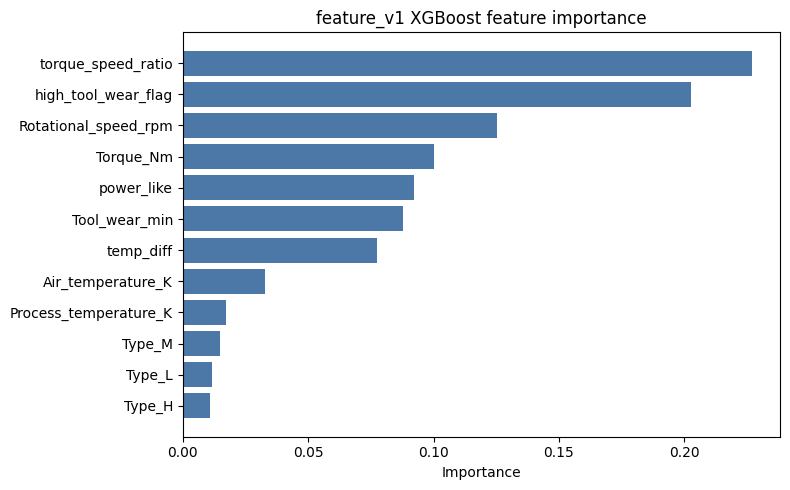

In [29]:
fig, ax = plt.subplots(figsize=(8, 5))
plot_importance = feature_v1_importance.head(12)
ax.barh(plot_importance["feature"], plot_importance["importance"], color="#4C78A8")
ax.invert_yaxis()
ax.set_title("feature_v1 XGBoost feature importance")
ax.set_xlabel("Importance")
plt.tight_layout()
plt.show()


## 13. Day2 业务特征工程小结

Day2 只加入了 4 个业务特征：`temp_diff`、`power_like`、`torque_speed_ratio` 和 `high_tool_wear_flag`。它们分别对应热状态、简化负载/功率、低转速高扭矩状态，以及高刀具磨损风险。所有特征都来自原始运行状态字段，没有使用 `TWF/HDF/PWF/OSF/RNF`，因此没有引入故障原因标签泄漏。

和原始 baseline 相比，`feature_v1` 的 Average Precision 从约 `0.721` 提升到约 `0.840`，说明新增业务特征改善了故障概率排序能力。

在 `0.50` 默认阈值下，`feature_v1` 的 precision 从 `0.293` 提升到 `0.398`，recall 从 `0.882` 提升到 `0.941`，F1 从 `0.440` 提升到 `0.559`，FN 从 `8` 降到 `4`，FP 从 `145` 降到 `97`。

在 Day1 推荐作为主要参考的 `0.80` 阈值下，`feature_v1` 的 precision 从 `0.602` 提升到 `0.750`，recall 从 `0.779` 提升到 `0.838`，F1 从 `0.679` 提升到 `0.792`，F2 从 `0.736` 提升到 `0.819`，FP 从 `35` 降到 `19`，FN 从 `15` 降到 `11`。这个阈值下的提升最适合作为后续分析主结果。

在 `0.40` 召回优先阈值下，`feature_v1` 也把 precision 从 `0.265` 提升到 `0.330`，recall 从 `0.926` 提升到 `0.941`，说明业务特征没有破坏筛查型场景下的召回优势。

从简单 feature importance 看，`torque_speed_ratio`、`high_tool_wear_flag`、`power_like` 和 `temp_diff` 都进入了模型使用范围，说明这些业务特征不是纯粹装饰。当前值得保留 `feature_v1`，尤其是在 `0.80` 阈值下继续作为后续优化参考。

下一步不建议继续盲目堆更多特征。更合理的是进入交叉验证和轻量调参：先验证 `feature_v1` 在不同数据划分下是否稳定，再围绕 XGBoost 做小范围参数调整，判断提升是否具有稳健性。


## 14. GridSearchCV 调参与错误样本分析

Day3 只保留必要流程：`GridSearchCV`、测试集阈值对照、FP/FN 错误样本分析。

`GridSearchCV(cv=...)` 本身已经包含 K 折交叉验证，因此这里不再额外使用 `cross_val_score`，避免重复代码和重复计算。

### 14.1 GridSearchCV 参数搜索

这里给出一组小范围参数搜索空间。默认 `RUN_GRID_SEARCH = False`，避免每次运行 notebook 都触发较慢搜索；需要正式调参时改成 `True` 后运行本单元即可。

In [30]:
from sklearn.model_selection import StratifiedKFold, GridSearchCV


RUN_GRID_SEARCH = True


cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

param_grid = {
    "n_estimators": [120, 180, 240],
    "max_depth": [2, 3, 4],
    "learning_rate": [0.05, 0.08],
    "min_child_weight": [1, 3, 5],
    "gamma": [0, 0.1],
    "reg_lambda": [1, 2],
    "subsample": [0.8, 0.9],
    "colsample_bytree": [0.8, 0.9],
}

grid_base_model = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    tree_method="hist",
    scale_pos_weight=scale_pos_weight,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

grid_search = GridSearchCV(
    estimator=grid_base_model,
    param_grid=param_grid,
    scoring="average_precision",
    cv=cv,
    n_jobs=-1,
    verbose=2,
)

if RUN_GRID_SEARCH:
    grid_search.fit(X_train_feature_v1, y_train)
    print("Best params:")
    print(grid_search.best_params_)
    print("Best CV average precision:", round(grid_search.best_score_, 4))
else:
    print("GridSearchCV 已准备好。将 RUN_GRID_SEARCH 改为 True 后运行。")

Fitting 5 folds for each of 864 candidates, totalling 4320 fits
Best params:
{'colsample_bytree': 0.8, 'gamma': 0.1, 'learning_rate': 0.05, 'max_depth': 4, 'min_child_weight': 5, 'n_estimators': 180, 'reg_lambda': 1, 'subsample': 0.8}
Best CV average precision: 0.86


### 14.2 测试集阈值对照

如果已经运行 GridSearchCV，本节使用 `grid_search.best_estimator_`；否则沿用 Day2 的 `feature_v1` 默认 XGBoost，保证 notebook 默认可以直接跑通。

In [31]:
if hasattr(grid_search, "best_estimator_"):
    day3_model_name = "feature_v1_grid_search_best"
    day3_model = grid_search.best_estimator_
else:
    day3_model_name = "feature_v1_default"
    day3_model = XGBClassifier(
        n_estimators=120,
        max_depth=3,
        learning_rate=0.08,
        subsample=0.9,
        colsample_bytree=0.9,
        objective="binary:logistic",
        eval_metric="logloss",
        tree_method="hist",
        scale_pos_weight=scale_pos_weight,
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )
    day3_model.fit(X_train_feature_v1, y_train)

y_proba_day3 = day3_model.predict_proba(X_test_feature_v1)[:, 1]

day3_holdout_comparison = pd.DataFrame(
    evaluate_model_thresholds(day3_model_name, y_proba_day3, [0.50, 0.80, 0.40])
)

day3_holdout_comparison = day3_holdout_comparison[
    ["version", "threshold", "precision", "recall", "f1", "f2", "average_precision", "TP", "FP", "TN", "FN"]
]

day3_holdout_comparison.round(3)

,version,threshold,precision,recall,f1,f2,average_precision,TP,FP,TN,FN
0,feature_v1_grid_search_best,0.5,0.538,0.926,0.681,0.810,0.883,63,54,1878,5
1,feature_v1_grid_search_best,0.8,0.795,0.853,0.823,0.841,0.883,58,15,1917,10
2,feature_v1_grid_search_best,0.4,0.453,0.926,0.609,0.766,0.883,63,76,1856,5


### 14.3 FP / FN 错误样本分析

错误分析固定使用当前主参考阈值 `0.80`。`TWF/HDF/PWF/OSF/RNF` 不参与训练，只在查看漏报样本时作为辅助解释字段。

In [32]:
day3_threshold = 0.80
day3_pred = (y_proba_day3 >= day3_threshold).astype(int)

print("Model:", day3_model_name)
print("Threshold:", day3_threshold)
print("Confusion matrix:")
print(confusion_matrix(y_test, day3_pred, labels=[0, 1]))

pd.DataFrame([
    threshold_metrics(y_test, y_proba_day3, day3_threshold)
]).round(3)

Model: feature_v1_grid_search_best
Threshold: 0.8
Confusion matrix:
[[1917   15]
 [  10   58]]


,threshold,precision,recall,f1,f2,TP,FP,TN,FN
0,0.8,0.795,0.853,0.823,0.841,58,15,1917,10


In [33]:
day3_error_df = df.loc[X_test.index].copy()
day3_error_df["y_true"] = y_test.values
day3_error_df["y_score"] = y_proba_day3
day3_error_df["y_pred"] = day3_pred

conditions = [
    (day3_error_df["y_true"] == 1) & (day3_error_df["y_pred"] == 1),
    (day3_error_df["y_true"] == 0) & (day3_error_df["y_pred"] == 1),
    (day3_error_df["y_true"] == 0) & (day3_error_df["y_pred"] == 0),
    (day3_error_df["y_true"] == 1) & (day3_error_df["y_pred"] == 0),
]
day3_error_df["error_group"] = np.select(
    conditions,
    ["TP", "FP", "TN", "FN"],
    default="UNKNOWN",
)
day3_error_df = add_feature_v1_business_features(day3_error_df)

day3_error_summary = pd.DataFrame({
    "count": day3_error_df["error_group"].value_counts(),
    "high_tool_wear_rate": day3_error_df.groupby("error_group")["high_tool_wear_flag"].mean(),
}).reindex(["TP", "FP", "TN", "FN"])

day3_error_summary.round(3)

,count,high_tool_wear_rate
error_group,,
TP,58,0.293
FP,15,0.800
TN,1917,0.068
FN,10,0.700


In [34]:
pd.crosstab(day3_error_df["error_group"], day3_error_df["Type"]).reindex(["TP", "FP", "TN", "FN"])

Type,H,L,M
error_group,,,
TP,5,32,21
FP,1,11,3
TN,208,1121,588
FN,0,6,4


In [35]:
day3_error_numeric_summary = (
    day3_error_df
    .groupby("error_group")[
        [
            "Rotational speed [rpm]",
            "Torque [Nm]",
            "Tool wear [min]",
            "torque_speed_ratio",
            "y_score",
        ]
    ]
    .mean()
    .reindex(["TP", "FP", "TN", "FN"])
)

day3_error_numeric_summary.round(3)

,Rotational speed [rpm],Torque [Nm],Tool wear [min],torque_speed_ratio,y_score
error_group,,,,,
TP,1458.983,52.817,143.966,0.039,0.964
FP,1452.333,47.347,188.733,0.034,0.900
TN,1539.129,39.500,106.820,0.026,0.042
FN,1599.000,34.720,207.600,0.023,0.355


In [36]:
day3_fn_samples = (
    day3_error_df[day3_error_df["error_group"] == "FN"]
    .sort_values("y_score", ascending=False)
    [
        [
            "UDI",
            "Type",
            "y_score",
            "Rotational speed [rpm]",
            "Torque [Nm]",
            "Tool wear [min]",
            "torque_speed_ratio",
            "TWF",
            "HDF",
            "PWF",
            "OSF",
            "RNF",
        ]
    ]
)

day3_fn_samples.round(3)

,UDI,Type,y_score,Rotational speed [rpm],Torque [Nm],Tool wear [min],torque_speed_ratio,TWF,HDF,PWF,OSF,RNF
4034,4035,L,0.782,1615,29.0,235,0.018,1,0,0,0,0
9015,9016,L,0.776,1431,49.7,210,0.035,0,0,0,0,0
3695,3696,L,0.576,1530,37.3,207,0.024,1,0,0,0,0
7087,7088,L,0.564,1648,30.5,217,0.019,1,0,0,0,0
7849,7850,M,0.530,1374,47.9,222,0.035,1,0,0,0,0
2671,2672,M,0.167,1399,41.9,221,0.030,1,0,0,0,0
2941,2942,M,0.122,1996,19.8,203,0.010,1,0,0,0,0
9174,9175,L,0.012,1871,25.6,200,0.014,1,0,0,0,0
8506,8507,L,0.009,1710,27.3,163,0.016,0,0,0,0,0
1996,1997,M,0.007,1416,38.2,198,0.027,1,0,0,0,0


## 15. Day3 小结

## Day3 总结报告：XGBoost 轻量调参与错误样本分析

Day3 的目标是在 Day2 已经验证有效的 `feature_v1` 基础上，进一步确认：通过轻量调参能否提升模型效果，以及当前模型的误报和漏报主要来自哪些业务场景。本轮没有新增特征，也没有引入新的模型，而是继续围绕 `feature_v1 + XGBoost` 展开。

本次使用 `GridSearchCV(cv=5)` 对 XGBoost 做小范围参数搜索。网格搜索共评估 `864` 组参数，每组参数进行 `5` 折交叉验证，总计 `4320` 次模型拟合。最优参数组合为：

```python
{
    "colsample_bytree": 0.8,
    "gamma": 0.1,
    "learning_rate": 0.05,
    "max_depth": 4,
    "min_child_weight": 5,
    "n_estimators": 180,
    "reg_lambda": 1,
    "subsample": 0.8
}
```

最优交叉验证 Average Precision 为 `0.860`。相比 Day2 默认 `feature_v1` 在测试集上的 PR-AUC `0.840`，调参后的模型在测试集上进一步提升到 `0.883`。这说明本轮调参并不只是训练集内部交叉验证上的提升，而是已经转化为 holdout test 上更好的故障风险排序能力。

在当前主参考阈值 `0.80` 下，调参后的模型表现为：

| 模型版本 | 阈值 | Precision | Recall | F1 | F2 | PR-AUC | TP | FP | TN | FN |
|---|---:|---:|---:|---:|---:|---:|---:|---:|---:|---:|
| feature_v1_default | 0.80 | 0.750 | 0.838 | 0.792 | 0.819 | 0.840 | 57 | 19 | 1913 | 11 |
| feature_v1_grid_search_best | 0.80 | 0.795 | 0.853 | 0.823 | 0.841 | 0.883 | 58 | 15 | 1917 | 10 |

可以看到，调参后的模型同时提升了 precision 和 recall。误报从 `19` 降到 `15`，漏报从 `11` 降到 `10`，说明模型不是通过单纯减少故障预测数量来提高 precision，而是在整体风险排序和故障识别上都更稳了一些。因此，当前推荐模型可以更新为：

```text
feature_v1_grid_search_best + threshold 0.80
```

从不同阈值看，`0.80` 仍然是当前最适合作为主分析结果的阈值。它在 precision、recall、F1、F2 之间取得了最好的平衡。`0.50` 阈值下 recall 可以达到 `0.926`，FN 降到 `5`，但 FP 增加到 `54`，precision 降到 `0.538`，更适合作为偏召回的业务筛查方案。`0.40` 阈值虽然 recall 同样为 `0.926`，但 FP 增加到 `76`，precision 降到 `0.453`，相比 `0.50` 并没有带来额外召回收益，因此当前业务价值不如 `0.50`。

错误样本分析显示，调参后的模型已经比较稳定地抓住了典型故障模式：高扭矩、低转速、高 `torque_speed_ratio`，并且常伴随较高刀具磨损。TP 样本的平均转速为 `1458.983 rpm`，平均扭矩为 `52.817 Nm`，平均 `torque_speed_ratio` 为 `0.039`；而 TN 样本的平均转速为 `1539.129 rpm`，平均扭矩为 `39.500 Nm`，平均 `torque_speed_ratio` 为 `0.026`。这说明模型学到的主要故障信号与前期 EDA 和 SQL 分析结论一致：高负载、低转速和高磨损状态更容易与设备故障相关。

误报样本并不是完全随机噪声。FP 共 `15` 个，其中 `80.0%` 属于高磨损样本，平均刀具磨损为 `188.733 min`，平均扭矩为 `47.347 Nm`，平均转速为 `1452.333 rpm`，平均 `torque_speed_ratio` 为 `0.034`。这些样本虽然在标签上是正常样本，但运行状态已经接近风险区域。因此，从业务角度看，部分 FP 可以理解为“高风险但尚未发生故障”的设备状态，而不一定是完全无意义的误报。它们可能代表需要重点关注或提前巡检的边界样本。

漏报样本更值得关注。FN 共 `10` 个，其中 `70.0%` 属于高磨损样本，平均刀具磨损为 `207.600 min`，但平均扭矩只有 `34.720 Nm`，平均转速为 `1599.000 rpm`，平均 `torque_speed_ratio` 只有 `0.023`。这说明当前模型对“高磨损 + 高负载”故障识别较好，但对“高磨损 + 扭矩不高 + 转速不低”的低信号故障仍然容易漏掉。这类样本不像典型故障样本那样呈现高扭矩、低转速特征，因此模型给出的风险分数偏低。

从 FN 明细看，多个漏报样本的 `TWF=1`，说明它们很可能属于刀具磨损相关故障。但由于 `TWF/HDF/PWF/OSF/RNF` 是故障原因标签，不能作为训练特征使用，模型只能通过 `Tool wear [min]` 和 `high_tool_wear_flag` 间接捕捉这类故障。当前只使用 `Tool wear > 200` 作为简单高磨损标记，可能不足以表达刀具磨损风险的非线性变化。这也是后续优化最值得关注的方向。

从产品类型看，FP 中 `Type=L` 占 `11/15`，FN 中 `Type=L` 占 `6/10`，`Type=M` 占 `4/10`，`Type=H` 没有漏报。由于 `Type=L` 本身样本量最大，不能简单解释为 L 类型一定更容易出错，但可以说明当前剩余错误主要发生在样本最多、状态变化也更多的 L 类型上。后续如果继续分析，可以比较不同 Type 内部的错误率，而不是只看错误数量。

综上，Day3 的主要结论是：`feature_v1_grid_search_best` 相比 Day2 默认模型有明确提升，当前主模型应更新为调参后的 XGBoost，主阈值继续保留 `0.80`。该模型已经较好识别了高负载、低转速、高磨损相关的典型故障模式，同时减少了误报和漏报。但它对高磨损但负载信号不明显的故障仍然识别不足，尤其是部分疑似刀具磨损型故障容易被漏掉。

下一步不建议继续盲目扩大网格搜索，也不建议一次性堆很多新特征。更合理的 Day4 方向是围绕漏报样本做小规模、业务驱动的特征改进，例如更细的刀具磨损区间、磨损与 Type 的轻量交互、或针对高磨损低负载样本的风险表达。同时，也可以将 `0.80` 作为主业务阈值，将 `0.50` 作为召回优先的筛查阈值，用于不同维护成本场景下的业务对比。